# Practical 3: Vector Quantization

**Course:** WBCS032-05 Introduction to Machine Learning  
**Student Names:**  Winand Metz, Matthias Nijman  
**Student Numbers:**  S6417221, S4667999

---

## Assignment Overview

In this assignment, you will implement Winner-Takes-All unsupervised competitive learning (VQ) as discussed in class, using the Euclidean distance measure. You will work with the dataset `simplevqdata.csv`, which contains 1000 unlabeled two-dimensional data points.  

## 1. Introduction (1 point)

Describe the goal of this assignment.

**Your answer here:**  
The goal of this assignment is to implement, visualise and then discuss the unsupervised competitive learning algorithm 'Vector Quantization'. The visualization is done by plotting both the quantization error and the process of the prototypes.

## 2. Methods (3 points)

### 2.1 Explain Vector Quantization (0.5 points)

Explain the algorithm in a general manner.

**Your answer here:**

As an unsupervised data-reduction algorithm, it seeks to optimise a cost function and generally works by dividing data into groups having approximately the same number of points. Each group's centroid is its representative, as in K-means and some other clustering algorithms. To achieve this, a set of $k$ prototypes is defined in feature space and redistributed per prototype based on the smallest dissimilarity or distance from a sampled data point, scaled by the learning rate. The cost function quantifies the algorithm's performance and can generally be defined as the squared error of all smallest dissimilarities or distances.

### 2.2 Implementation (2.5 points)

You need to implement the VQ algorithm **yourself**. Both the code quality and correctness will be graded.

*__Note:__* **Do not change the cell labels! Themis will use them to automatically grade your submission.**

In [295]:
# Load required libraries
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Read the file containing the data
data_file_path = 'simplevqdata.csv'

# The values below are sample values
num_prototypes = 2 # the number of prototypes
learning_rate = 0.1 # the learning rate
t_max = 100 # the maximum number of epochs

np.random.seed(0)

In [296]:
# Read input data

df = pd.read_csv(data_file_path, header=None)
data = np.array(df)

In [297]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   0       1000 non-null   float64
 1   1       1000 non-null   float64
dtypes: float64(2)
memory usage: 15.8 KB


Text(0, 0.5, 'Second feature')

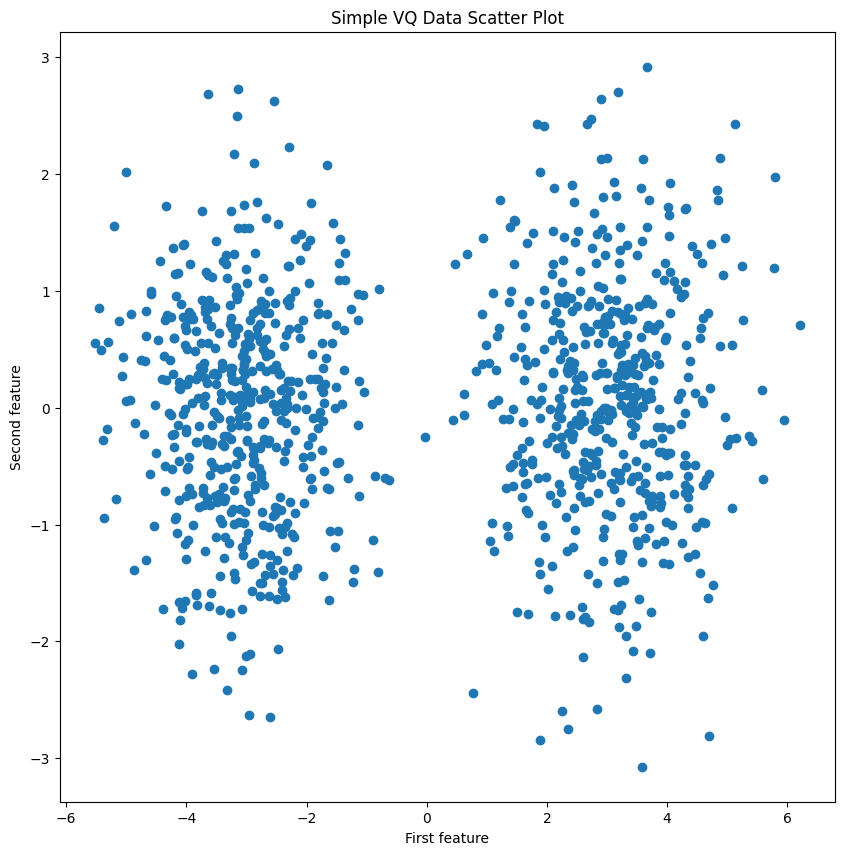

In [298]:
plt.figure(figsize=(10, 10))
plt.scatter(df[0], df[1])
plt.title("Simple VQ Data Scatter Plot")
plt.xlabel("First feature")
plt.ylabel("Second feature")

#### VQ Algorithm Steps

Implement the following steps:

1. **Initialize the prototypes, e.g., by random selection of K data points**

2. **Repeat for epochs $t = 1$ to $t_{max}$:**

      

      *   In each epoch, present all of the dataset in a randomized order (every example is presented exactly once, the order of examples is different in every epoch)

      *   perform an epoch of training using all of the P examples. At every individual step present a single example to the system, evaluate the distances from all prototypes and update the winning prototype

      *   plot the data and prototype positions after each epoch, so you can observe/show how they approach their final positions

      *   evaluate the quantization error HV Q after each epoch (not after each individual update step!)


In [299]:
def d(a, b):
    diff = a - b

    return np.dot(diff, diff)


def quantization_error(data, prototypes):
    """
    Compute quantization error

    Args:
        data (ndarray): Data points.
        prototypes (ndarray): The prototypes

    Returns:
        HVQ (float): quantization error
    """    
    return np.sum([np.min([d(u, j) for j in prototypes]) for u in data])

In [300]:
def initialize_prototypes(data, num_prototypes, init_type):
    """
    Initializes prototypes

    Args:
        data (ndarray): Data points
        num_prototypes (int): The number of prototypes
        init_type (str): Initialization type ('random' or 'stupid')

    Returns:
        prototypes (ndarray): The prototypes
    """
    if init_type == 'random':
        # Choose random data points as initial prototypes
        return data[np.random.choice(data.shape[0], num_prototypes, replace=False)]

    if init_type == 'stupid':
        # Generate points in the bottom left corner
        return np.add(np.min(data, 0), np.random.rand(num_prototypes,2))
    
    # else
    return np.ndarray((0,2))


def vector_quantization(data, num_prototypes, learning_rate, max_epoch, init_type='random'):
    """
    Competitive learning with vector quantization

    Args:
        data (ndarray): Data points
        num_prototypes (int): The number of prototypes
        learning_rate (float): The learning rate
        max_epoch (int): The maximum number of epochs
        init_type (str): Initialization type ('random' or 'stupid')

    Returns:
        prototype_trace (list): The trace of the prototypes over all epochs
        HVQ_trace (list): The quantization error over all epochs
    """
    prototypes = initialize_prototypes(data, num_prototypes, init_type)

    prototype_trace = [prototypes.copy()]
    HVQ_trace = []

    for e in range(max_epoch):
        per_data = np.random.permutation(data)

        for p in per_data:
            # Compute index of the winner
            i = np.argmin([np.linalg.norm(w - p) for w in prototypes])
            # Update the winner
            prototypes[i] = prototypes[i] + learning_rate * (p - prototypes[i])
        
        # Update traces
        prototype_trace += [prototypes.copy()]
        HVQ_trace += [quantization_error(per_data, prototypes)]

    return prototype_trace, HVQ_trace

## 3. Experimental Results (4 points)

### 3.1 Learning curves

*__Note:__* This section **is graded** by Themis.

Implement the function below in order to generate plots of the quantization error $H_{VQ}$ as a function of the number of epochs $t$. Include learning curve figures for three different learning rate values $\eta$, considering prototype counts $K = 2$ and $K = 4$.

Initialize the prototypes using randomly selected data points.

In [301]:
def plot_quantization_error(data, num_prototypes, learning_rate, t_max):
    """
    Plot quantization error over epochs.

    Args:
        data (ndarray): Data points.
        num_prototypes (int): Number of prototypes.
        learning_rate (float): Learning rate.
        t_max (int): Maximum number of epochs.
    """
    prototype_trace, HVQ_trace = vector_quantization(data, num_prototypes, learning_rate, t_max, init_type='random')

    plt.plot(range(1, len(HVQ_trace) + 1), HVQ_trace)
    plt.title(f"Quantization Error Over Epochs (k={num_prototypes}, lr={learning_rate})")
    plt.xlabel("Epoch")
    plt.ylabel("Quantization Error")

### 3.2 Trajectories of prototypes during learning

*__Note:__* This section is graded **both by Themis and manually**.

Implement the function below in order to generate plots that display the trajectories of the prototypes during learning for $K = 2$ and $K = 4$. The plots should illustrate the paths (traces) of the prototypes from their initial positions to their final positions, together with the data points.

Use a learning rate that produces non-trivial and meaningful learning behavior.

Perform the training using at least two different initialization strategies:
- One where the prototypes are initialized with randomly selected data points.
- One using a deliberately poor (“stupid”) initialization.

In [302]:
def plot_prototype_trajectories(data, num_prototypes, learning_rate, t_max, colors, init_type="random"):
    """
    Plot the trajectories of prototypes during VQ learning.

    Args:
        data (ndarray): Data points.
        num_prototypes (int): Number of prototypes.
        learning_rate (float): Learning rate.
        t_max (int): Maximum number of epochs.
        colors (list): List of colors, one per prototype.
        init_type (str): Initialization type ('random' or 'stupid').
    """
    prototype_trace, HVQ_trace = vector_quantization(data, num_prototypes, learning_rate, t_max, init_type='random')
    
    fig = plt.figure()
    ax = fig.add_subplot()

    x, y = zip(*data)
    ax.scatter(x, y, alpha=0.3)
    for i in range(num_prototypes):
        x, y = zip(*[prototype[i] for prototype in prototype_trace])
        ax.plot(x, y, c=colors[i], marker = 'o')

    plt.title(f"Trajectory of prototypes (k={num_prototypes}, lr={learning_rate}, init={init_type})")
    plt.xlabel("feature 1")
    plt.ylabel("feature 2")
    plt.legend(['Data points'] + [f'Prototype {i+1} Trajectory' for i in range(num_prototypes)], loc="lower center")


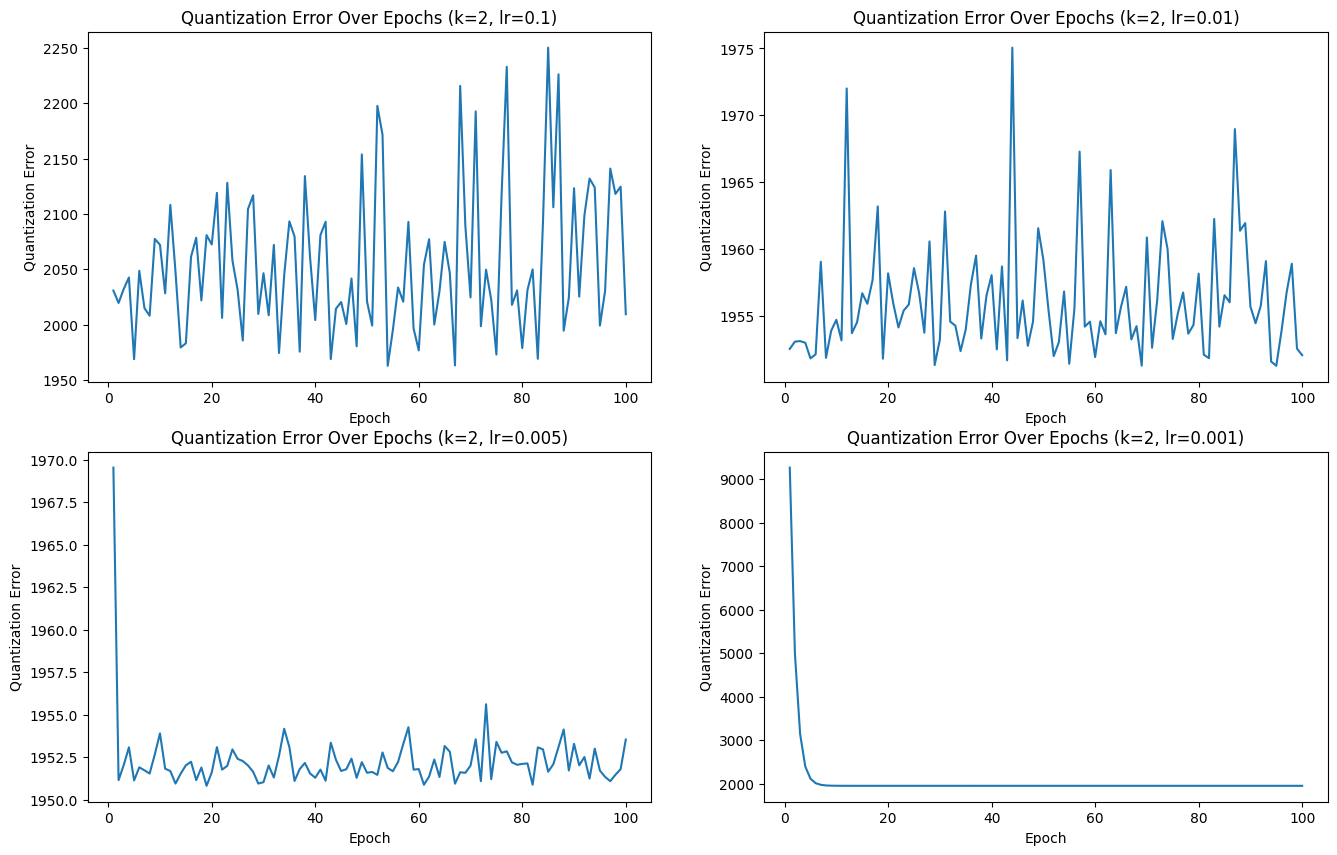

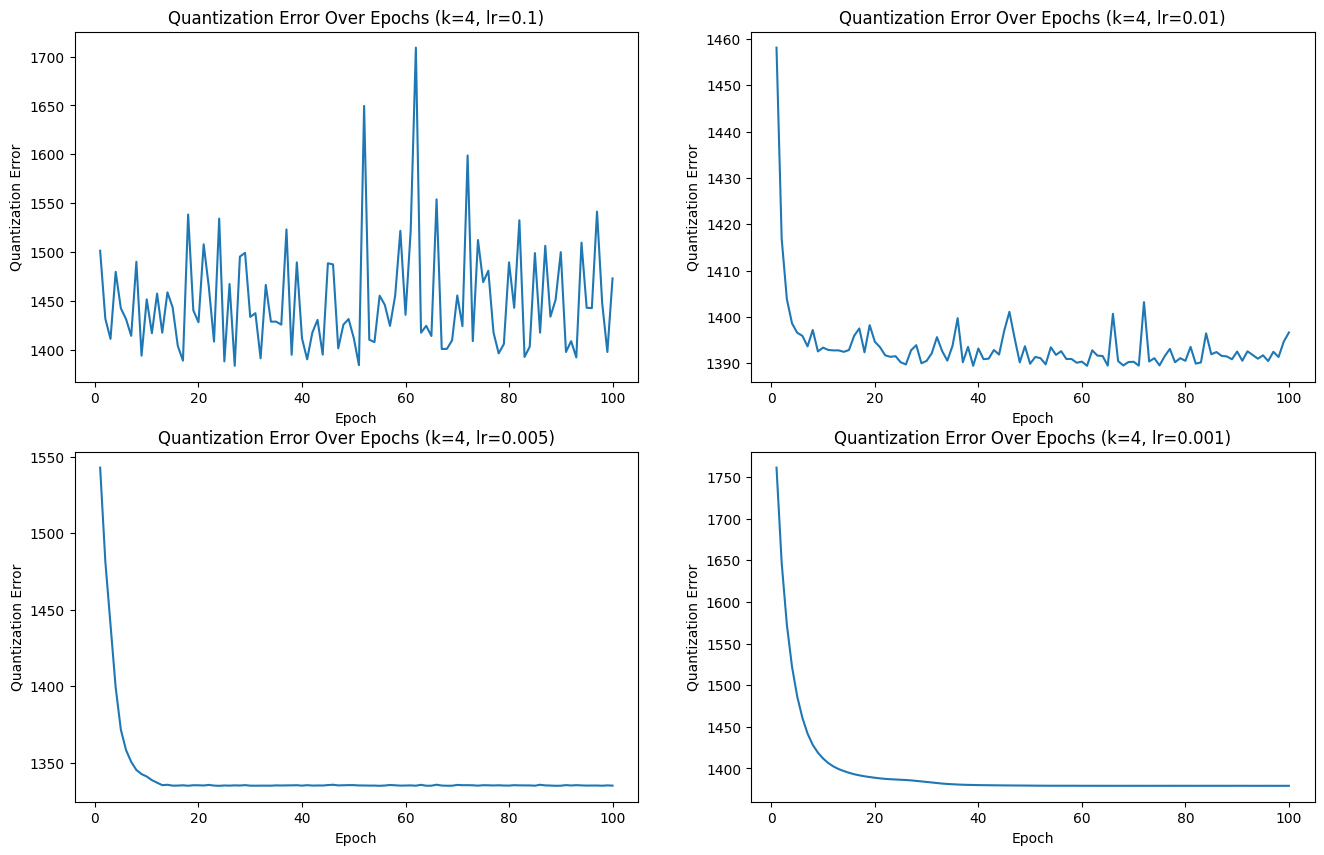

In [315]:
rates = [0.1, 0.01, 0.005, 0.001]

plt.figure(figsize=(16, 10))
for m in range(len(rates)):
    plt.subplot(2, 2, m+1)
    plot_quantization_error(data, num_prototypes=2, learning_rate=rates[m], t_max=100)
plt.show()

plt.figure(figsize=(16, 10))
for m in range(len(rates)):
    plt.subplot(2, 2, m+1)
    plot_quantization_error(data, num_prototypes=4, learning_rate=rates[m], t_max=100)
plt.show()

<Figure size 1600x1000 with 0 Axes>

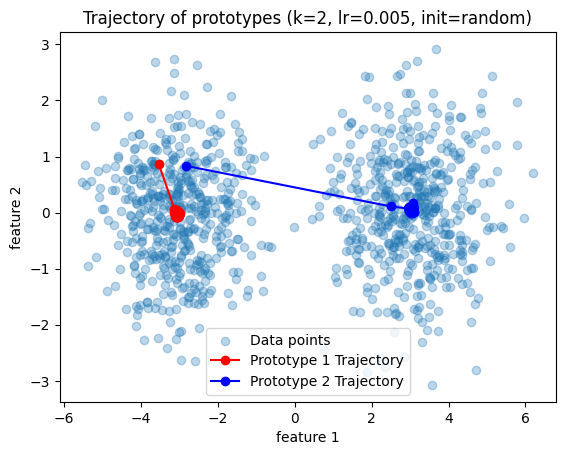

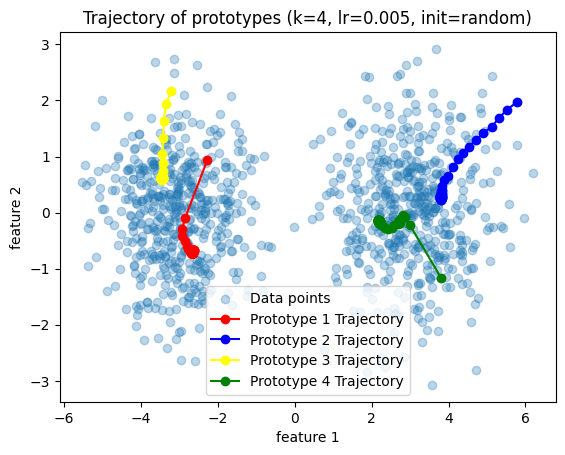

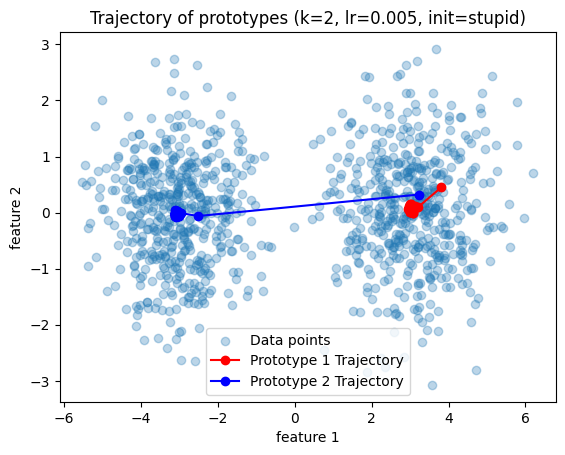

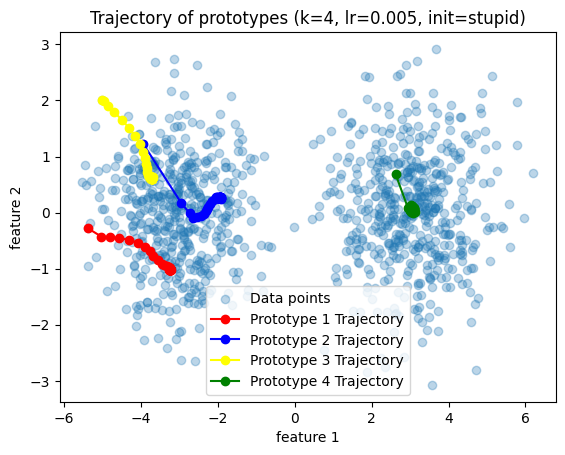

In [320]:
plt.figure(figsize=(16, 10))

plot_prototype_trajectories(data, num_prototypes=2, learning_rate=0.005, t_max=100, colors=['red', 'blue'], init_type="random")
plt.show()
plot_prototype_trajectories(data, num_prototypes=4, learning_rate=0.005, t_max=100, colors=['red', 'blue', 'yellow', 'green'], init_type="random")
plt.show()
plot_prototype_trajectories(data, num_prototypes=2, learning_rate=0.005, t_max=100, colors=['red', 'blue'], init_type="stupid")
plt.show()
plot_prototype_trajectories(data, num_prototypes=4, learning_rate=0.005, t_max=100, colors=['red', 'blue', 'yellow', 'green'], init_type="stupid")
plt.show()

## 4. Discussion (2 points)

Discuss your observations on the obtained results, in particular with respect to the role of the learning rate, addressing the following questions:

- How does the final value of the cost function change with $\eta$?
- What happens if $\eta$ is too large or too small?

**Your answer here:**



## Contribution

State your individual contribution.

**Your answer here:**  
We worked with pair-programming and we have contributed equally to the assignment.